In [1]:
import time

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
from pyhgf.rshgf import Network as RsNetwork

from pyhgf import load_data
from pyhgf.distribution import HGFDistribution, HGFPointwise
from pyhgf.model import HGF
from pyhgf.model import Network as PyNetwork
from pyhgf.response import binary_softmax, binary_softmax_inverse_temperature

plt.rcParams["figure.constrained_layout.use"] = True

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
u, y = load_data("binary")

# Subject-level fit

In [3]:
hgf_logp_op = HGFDistribution(
    n_levels=3,
    model_type="binary",
    input_data=u[
        np.newaxis, :
    ],  # the inputs are the same for all agents - just duplicate the array
    response_function=binary_softmax_inverse_temperature,
    response_function_inputs=y[np.newaxis, :],
)

In [4]:
def logp(value, tonic_volatility_2, inverse_temperature):
    """Log-probability function for the HGF model with given parameters."""
    return hgf_logp_op(
        tonic_volatility_2=tonic_volatility_2,
        response_function_parameters=inverse_temperature,
    )

In [5]:
with pm.Model() as two_levels_binary_hgf:
    # tonic volatility
    tonic_volatility_2 = pm.Uniform("tonic_volatility_2", -6.0, -0.5)

    # inverse temperature
    inverse_temperature = pm.Uniform("inverse_temperature", 0.1, 6.0)

    # The multi-HGF distribution
    # --------------------------
    log_likelihood = pm.CustomDist(
        "log_likelihood", tonic_volatility_2, inverse_temperature, logp=logp, observed=y
    )

    two_level_hgf_idata = pm.sample(chains=4, cores=1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [tonic_volatility_2, inverse_temperature]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


In [6]:
tonic_volatility_2 = az.summary(two_level_hgf_idata)["mean"]["tonic_volatility_2"]
inverse_temperature = az.summary(two_level_hgf_idata)["mean"]["inverse_temperature"]

In [7]:
hgf_mcmc = HGF(
    n_levels=3,
    model_type="binary",
    initial_mean={"1": jnp.nan, "2": 0.0, "3": 0.0},
    initial_precision={"1": 0.0, "2": 1.0, "3": 1.0},
    tonic_volatility={"1": jnp.nan, "2": tonic_volatility_2, "3": -4.0},
).input_data(input_data=u)

# Beliefs trajectories

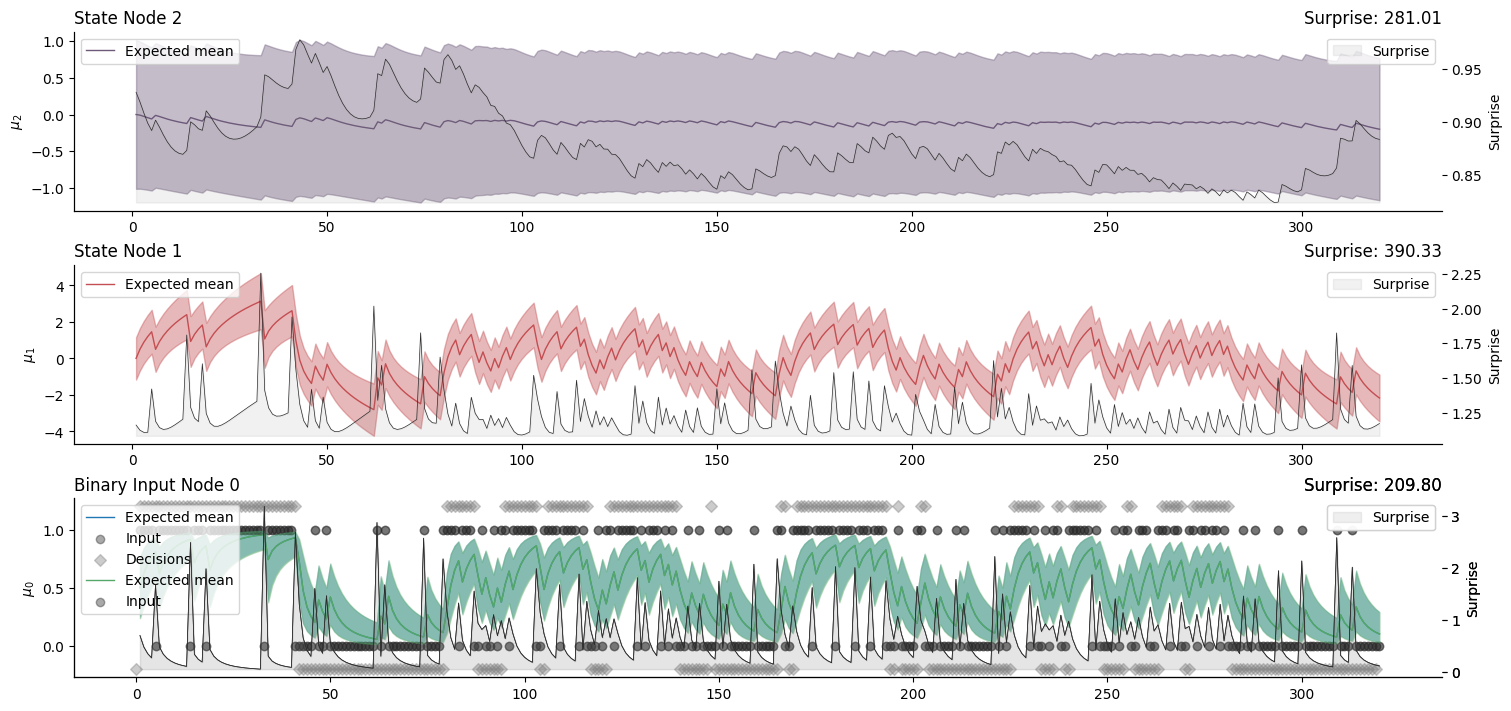

In [8]:
fig, axs = plt.subplots(figsize=(15, 7), nrows=3)

hgf_mcmc.plot_nodes(node_idxs=0, axs=axs[-1])
axs[-1].scatter(
    x=np.arange(len(y)),
    y=y * 1.4 - 0.2,
    label="Decisions",
    alpha=0.4,
    marker="D",
    color="grey",
    zorder=-2,
)
axs[-1].legend()

hgf_mcmc.plot_nodes(node_idxs=0, axs=axs[-1], color="#55a868")
hgf_mcmc.plot_nodes(node_idxs=1, axs=axs[-2], color="#c44e52")
hgf_mcmc.plot_nodes(node_idxs=2, axs=axs[-3], color="#6d597a")

sns.despine()
plt.savefig("binary_trajectories.pdf", dpi=600)

# Traces

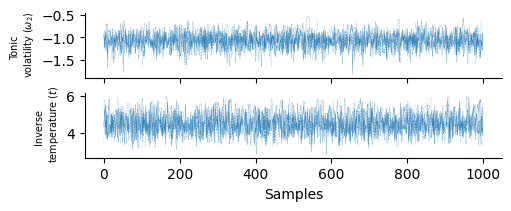

In [9]:
_, axs = plt.subplots(nrows=2, figsize=(5, 2), sharex=True)
for i, var_name in enumerate(["tonic_volatility_2", "inverse_temperature"]):
    for ii, st in zip(range(4), ["-", "--", ":", "-."]):
        axs[i].plot(
            two_level_hgf_idata["posterior"][var_name][ii],
            linewidth=0.2,
            color="#1f77b4",
            linestyle=st,
        )

axs[0].set_ylabel("Tonic \n volatility " r"($\omega_2$)", size=7)
axs[1].set_ylabel("Inverse \n temperature " r"($t$)", size=7)

axs[1].set_xlabel("Samples", size=10)
sns.despine()
plt.savefig("binary_traces.pdf", dpi=600)

# Posterior

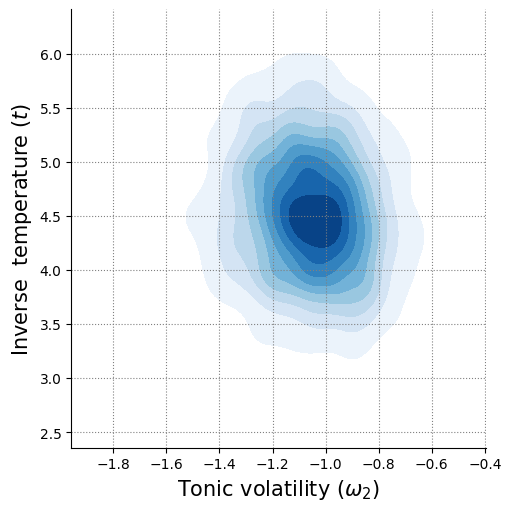

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.kdeplot(
    x=two_level_hgf_idata["posterior"]["tonic_volatility_2"].to_numpy().flatten(),
    y=two_level_hgf_idata["posterior"]["inverse_temperature"].to_numpy().flatten(),
    ax=ax,
    fill=True,
    cmap="Blues",
)
ax.grid(color="grey", linestyle="dotted", zorder=3)
ax.set_xlabel(r"Tonic volatility ($\omega_2$)", size=15)
ax.set_ylabel(r"Inverse  temperature ($t$)", size=15)
sns.despine()
plt.savefig("binary_posterior.pdf", dpi=600)

# Parameters recovery

In [11]:
N = 50  # the number of agents to simulate

# sample one value for the inverse temperature (here in log space) and simulate responses
temperatures = np.linspace(0.5, 6.0, num=N)

# sample one new value of the tonic volatility at the second level and fit to observations
volatilities = np.linspace(-5.5, -1.0, num=N)

In [12]:
def sigmoid(x, temperature):
    """Return the sigmoid response function with an inverse temperature parameter."""
    return (x**temperature) / (x**temperature + (1 - x) ** temperature)

In [13]:
# create just one default network - we will simply change the values of interest before fitting to save time
agent = HGF(
    n_levels=3,
    model_type="binary",
    initial_mean={"1": 0.5, "2": 0.0, "3": 0.0},
)

In [14]:
np.random.seed(123)

# observations (always the same), simulated decisions, sample values for temperature and volatility
responses = []
for i in range(N):
    # set the tonic volatility for this agent and run the perceptual model forward
    agent.attributes[1]["tonic_volatility"] = volatilities[i]
    agent.input_data(input_data=u)

    # get decision probabilities using the belief trajectories
    # and the sigmoid decision function with inverse temperature
    p = sigmoid(
        x=agent.node_trajectories[0]["expected_mean"], temperature=temperatures[i]
    )

    # save the observations and decisions separately
    responses.append(np.random.binomial(p=p, n=1))

responses = np.array(responses)

In [15]:
hgf_model_comparison_logp_op = HGFDistribution(
    n_levels=3,
    model_type="binary",
    input_data=u[np.newaxis, :].repeat(
        N, axis=0
    ),  # the inputs are the same for all agents - duplicate the array
    response_function=binary_softmax_inverse_temperature,
    response_function_inputs=responses,
)

In [16]:
hgf_logp_op_pointwise = HGFPointwise(
    n_levels=3,
    model_type="binary",
    input_data=u[np.newaxis, :].repeat(
        N, axis=0
    ),  # the inputs are the same for all agents - duplicate the array
    response_function=binary_softmax_inverse_temperature,
    response_function_inputs=responses,
)

In [17]:
def logp(value, tonic_volatility_2, inverse_temperature):
    """Return the log-probability."""
    return hgf_model_comparison_logp_op(
        tonic_volatility_2=tonic_volatility_2,
        response_function_parameters=pt.flatten(inverse_temperature),
    )

In [18]:
def logp_pointwise(tonic_volatility_2, inverse_temperature):
    """Return the pointwise log-probability."""
    return hgf_logp_op_pointwise(
        tonic_volatility_2=tonic_volatility_2,
        response_function_parameters=inverse_temperature,
    )

In [19]:
with pm.Model() as two_levels_binary_hgf:
    response_data = pm.Data("response_data", responses, dims=["subject", "trials"])

    # tonic volatility
    tonic_volatility_2 = pm.Uniform(
        "tonic_volatility_2", -6.0, -0.5, shape=(N,), dims="subject"
    )

    # inverse temperature
    inverse_temperature = pm.Uniform(
        "inverse_temperature", 0.1, 7.0, shape=(N,), dims="subject"
    )

    # The multi-HGF distribution
    # --------------------------
    log_likelihood = pm.CustomDist(
        "log_likelihood",
        tonic_volatility_2,
        inverse_temperature,
        logp=logp,
        observed=response_data,
    )

    pm.Deterministic(
        "pointwise_loglikelihood",
        logp_pointwise(tonic_volatility_2, inverse_temperature),
        dims=["subject", "trials"],
    )

In [20]:
with two_levels_binary_hgf:
    two_level_hgf_idata = pm.sample(chains=2, cores=1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [tonic_volatility_2, inverse_temperature]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 323 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [21]:
two_level_hgf_idata.add_groups(
    log_likelihood=two_level_hgf_idata.posterior["pointwise_loglikelihood"]
)

In [22]:
two_level_hgf_idata.to_netcdf("softmax_temperature.nc");

# Recovery plot

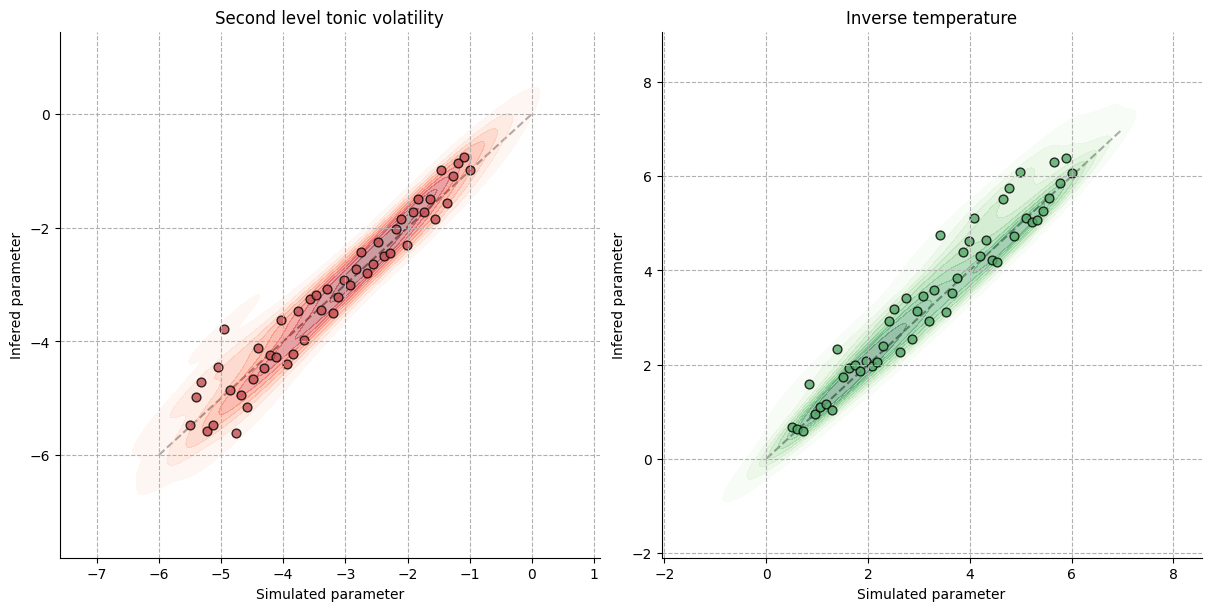

In [23]:
fig, axs = plt.subplots(figsize=(12, 6), ncols=2)

axs[0].plot([-6.0, 0.0], [-6.0, 0.0], color="grey", linestyle="--", zorder=-1)
axs[1].plot([0.0, 7.0], [0.0, 7.0], color="grey", linestyle="--", zorder=-1)

for var_name, refs, idx in zip(
    ["tonic_volatility_2", "inverse_temperature"],
    [volatilities, temperatures],
    [0, 1],
):
    inferred_parameters = az.summary(two_level_hgf_idata, var_names=var_name)[
        "mean"
    ].tolist()

    sns.kdeplot(
        x=refs,
        y=inferred_parameters,
        ax=axs[idx],
        fill=True,
        cmap="Reds" if var_name == "tonic_volatility_2" else "Greens",
        alpha=0.4,
    )

    axs[idx].scatter(
        refs,
        az.summary(two_level_hgf_idata, var_names=var_name)["mean"].tolist(),
        s=40,
        alpha=0.8,
        edgecolors="k",
        color="#c44e52" if var_name == "tonic_volatility_2" else "#55a868",
    )

    axs[idx].grid(True, linestyle="--")
    axs[idx].set_xlabel("Simulated parameter")
    axs[idx].set_ylabel("Infered parameter")

axs[0].set_title("Second level tonic volatility")
axs[1].set_title("Inverse temperature")
plt.savefig("parameter_recovery.pdf", dpi=600)
sns.despine()

# Multilevel model

In [24]:
with pm.Model() as two_levels_binary_hgf_multilevel:
    response_data = pm.Data("response_data", responses, dims=["subject", "trials"])

    # tonic volatility
    # ----------------
    mu_volatility = pm.Normal("mu_volatility", -5, 5)
    sigma_volatility = pm.HalfNormal("sigma_volatility", 10)
    tonic_volatility_2 = pm.Normal(
        "tonic_volatility_2",
        mu=mu_volatility,
        sigma=sigma_volatility,
        shape=(N,),
        dims="subject",
    )

    # inverse temperature
    # -------------------
    mu_temperature = pm.HalfNormal("mu_temperature", 1)
    sigma_temperature = pm.HalfNormal("sigma_temperature", 0.5)
    inverse_temperature = pm.LogNormal(
        "inverse_temperature",
        mu_temperature,
        sigma_temperature,
        shape=(N,),
        dims="subject",
    )

    # The multi-HGF distribution
    # --------------------------
    log_likelihood = pm.CustomDist(
        "log_likelihood",
        tonic_volatility_2,
        pt.log(inverse_temperature),
        logp=logp,
        observed=response_data,
    )

In [25]:
with two_levels_binary_hgf_multilevel:
    two_level_hgf_multilevel_idata = pm.sample(chains=4, cores=1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [mu_volatility, sigma_volatility, tonic_volatility_2, mu_temperature, sigma_temperature, inverse_temperature]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 631 seconds.
There were 30 divergences after tuning. Increase `target_accept` or reparameterize.


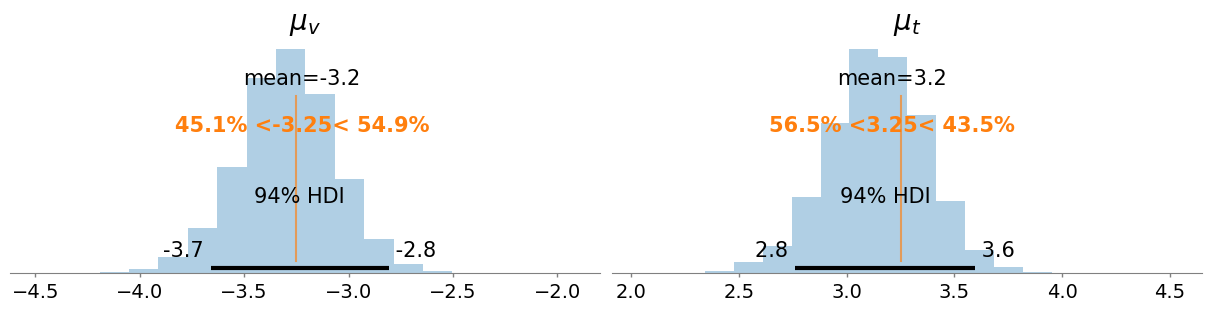

In [26]:
_, axs = plt.subplots(figsize=(12, 3), ncols=2)

az.plot_posterior(
    two_level_hgf_multilevel_idata,
    var_names=["mu_volatility", "mu_temperature"],
    ref_val=[volatilities.mean(), temperatures.mean()],
    kind="hist",
    ax=axs,
)

axs[0].set_title(r"$\mu_v$", size=20)
axs[1].set_title(r"$\mu_t$", size=20)
plt.savefig("multilevel.pdf", dpi=600)

# Model comparison

In [27]:
hgf_model_comparison_logp_op_softmax = HGFDistribution(
    n_levels=3,
    model_type="binary",
    input_data=u[np.newaxis, :].repeat(
        N, axis=0
    ),  # the inputs are the same for all agents - duplicate the array
    response_function=binary_softmax,
    response_function_inputs=responses,
)

In [28]:
hgf_logp_op_pointwise_softmax = HGFPointwise(
    n_levels=3,
    model_type="binary",
    input_data=u[np.newaxis, :].repeat(
        N, axis=0
    ),  # the inputs are the same for all agents - duplicate the array
    response_function=binary_softmax,
    response_function_inputs=responses,
)

In [29]:
def logp(value, tonic_volatility_2):
    """Return the log-probability."""
    return hgf_model_comparison_logp_op_softmax(
        tonic_volatility_2=tonic_volatility_2,
    )

In [30]:
def logp_pointwise(tonic_volatility_2):
    """Return the pointwise log-probability."""
    return hgf_logp_op_pointwise_softmax(
        tonic_volatility_2=tonic_volatility_2,
    )

In [31]:
with pm.Model() as two_levels_binary__sofmax_hgf:
    response_data = pm.Data("response_data", responses, dims=["subject", "trials"])

    # tonic volatility
    tonic_volatility_2 = pm.Uniform(
        "tonic_volatility_2", -7.0, -0.5, shape=(N,), dims="subject"
    )

    # The multi-HGF distribution
    # --------------------------
    log_likelihood = pm.CustomDist(
        "log_likelihood",
        tonic_volatility_2,
        logp=logp,
        observed=response_data,
    )

    pm.Deterministic(
        "pointwise_loglikelihood",
        logp_pointwise(tonic_volatility_2),
        dims=["subject", "trials"],
    )

In [32]:
with two_levels_binary__sofmax_hgf:
    two_level_hgf_softmax_idata = pm.sample(chains=2, cores=1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [tonic_volatility_2]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 193 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [33]:
two_level_hgf_softmax_idata.add_groups(
    log_likelihood=two_level_hgf_softmax_idata.posterior["pointwise_loglikelihood"]
)

In [34]:
two_level_hgf_softmax_idata.to_netcdf("softmax.nc");

In [35]:
two_level_hgf_idata = az.from_netcdf("softmax_temperature.nc")
two_level_hgf_softmax_idata = az.from_netcdf("softmax.nc")

In [36]:
az.loo(two_level_hgf_idata)

/home/nicolas/git/pyhgf/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 2000 posterior samples and 16000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -5981.15    63.57
p_loo       90.54        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15945   99.7%
   (0.70, 1]   (bad)          0    0.0%
   (1, Inf)   (very bad)    55    0.3%

In [37]:
az.loo(two_level_hgf_softmax_idata)

/home/nicolas/git/pyhgf/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 2000 posterior samples and 16000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -7532.28    37.35
p_loo       23.34        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15910   99.4%
   (0.70, 1]   (bad)         18    0.1%
   (1, Inf)   (very bad)    72    0.4%

In [38]:
compare_df = az.compare({
    "softmax": two_level_hgf_softmax_idata,
    "temperature_softmax": two_level_hgf_idata,
})

/home/nicolas/git/pyhgf/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/nicolas/git/pyhgf/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [39]:
compare_df

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
temperature_softmax,0,-5981.146378,90.544233,0.000000,1.0,63.565857,0.000000,True,log
softmax,1,-7532.280384,23.336344,1551.134006,0.0,37.348753,37.238227,True,log


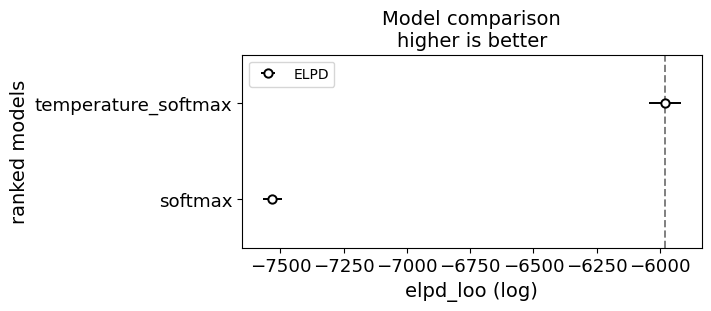

In [40]:
_, ax = plt.subplots(figsize=(7, 3))

az.plot_compare(compare_df, figsize=(9, 3), ax=ax)
plt.legend(loc="upper left")
plt.savefig("model_comparison.pdf", dpi=600)

# Code examples

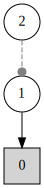

In [41]:
from pyhgf.model import Network

# create a new network --------------------------------
# This structure is known as the three-level binary HGF
binary_hgf = (
    Network()
    .add_nodes(kind="binary-state")
    .add_nodes(kind="continuous-state", value_children=0)
    .add_nodes(kind="continuous-state", volatility_children=1)
)

# visualisation utility to inspect the network's structure
binary_hgf.plot_network()

array([<Axes: title={'left': 'State Node 2'}, ylabel='$\\mu_{2}$'>,
       <Axes: title={'left': 'State Node 1'}, ylabel='$\\mu_{1}$'>,
       <Axes: title={'left': 'Binary Input Node 0'}, xlabel='Time', ylabel='$\\mu_{0}$'>],
      dtype=object)

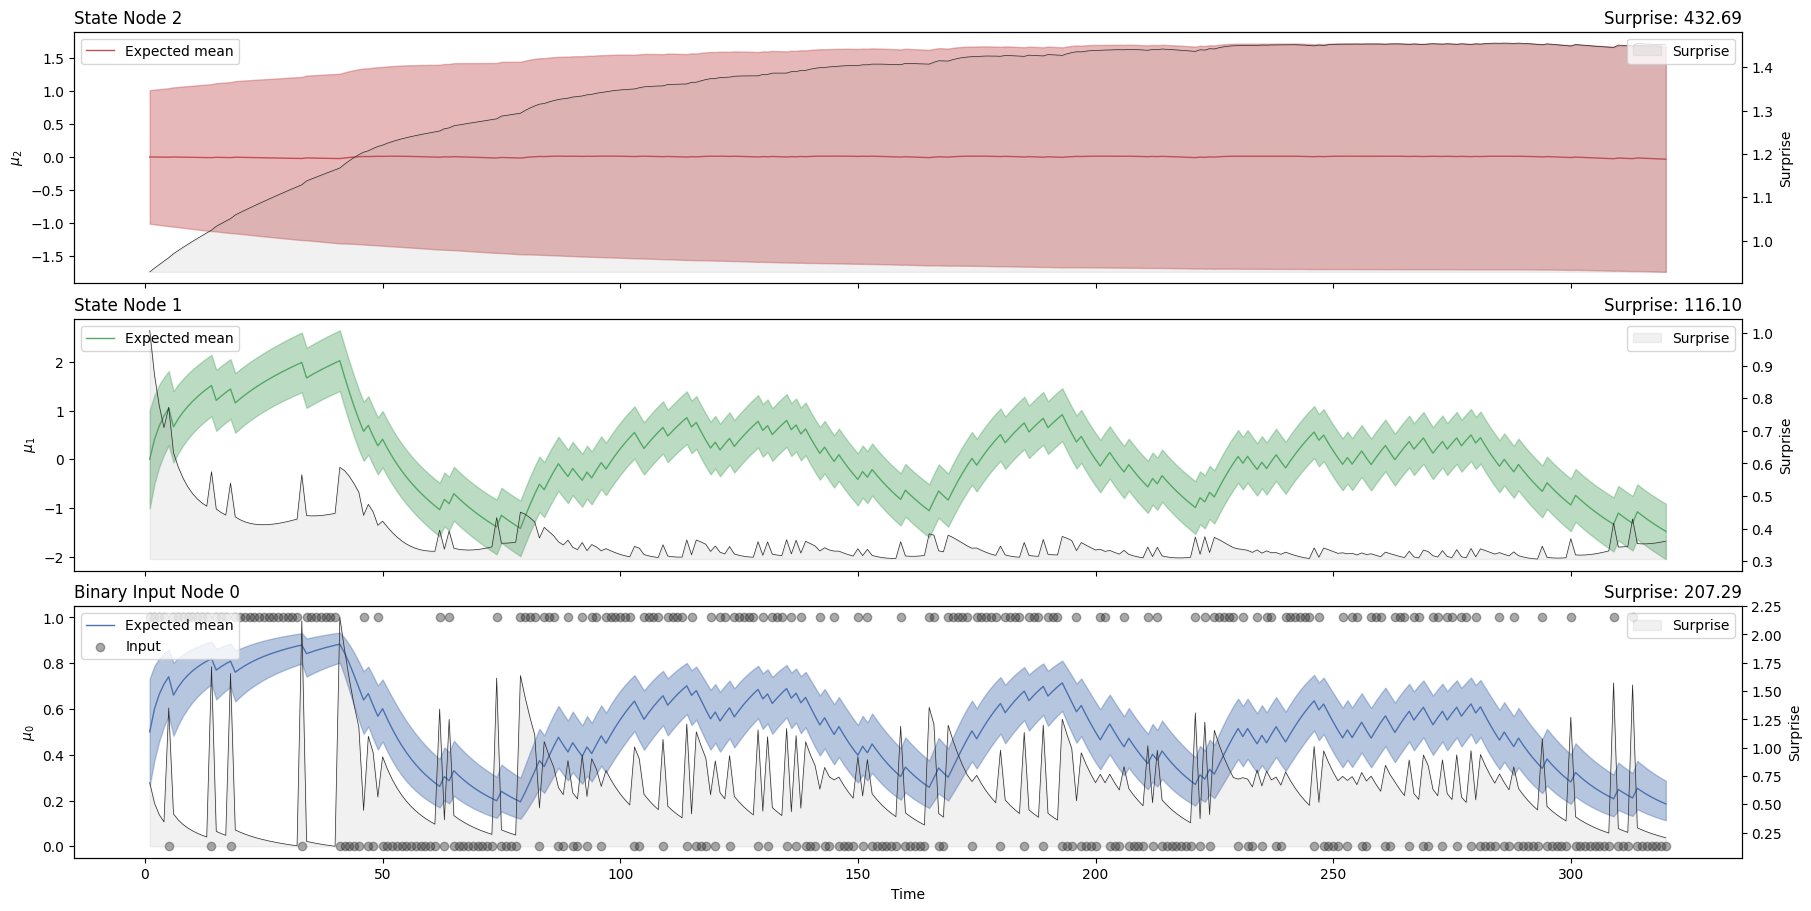

In [42]:
from pyhgf import load_data

u, y = load_data("binary")

# provide a vector of binary observations to the network
binary_hgf.input_data(input_data=u)

# visualisation utility to inspect beliefs trajectories
binary_hgf.plot_trajectories()

In [43]:
import jax.numpy as jnp

from pyhgf.math import binary_surprise


def binary_softmax(
    hgf,
    response_function_inputs,
    response_function_parameters,
):
    """Surprise under the binary sofmax model."""
    # the expected values at the first level of the HGF
    beliefs = hgf.node_trajectories[0]["expected_mean"]

    # the binary surprises
    surprise = binary_surprise(x=response_function_inputs, expected_mean=beliefs)

    # ensure that inf is returned if the model cannot fit
    surprise = jnp.where(jnp.isnan(surprise), jnp.inf, surprise)

    return surprise


# compute the sum of the binary surprise
# lower values indicate that the model is a better fit to the participant's behavior
binary_hgf.surprise(response_function=binary_softmax, response_function_inputs=y).sum()

Array(163.46918, dtype=float32)

In [44]:
import pymc as pm

from pyhgf.distribution import HGFDistribution

hgf_logp_op = HGFDistribution(
    n_levels=2,
    model_type="binary",
    input_data=u[jnp.newaxis, :],
    response_function=binary_softmax,
    response_function_inputs=y[jnp.newaxis, :],
)

with pm.Model() as three_levels_binary_hgf:
    # Set a prior over the evolution rate at the second level.
    tonic_volatility_2 = pm.Uniform("tonic_volatility_2", -3.5, 0.0)

    # Call the pre-parametrized HGF distribution here.
    # All parameters are set to their default value, except omega_2.
    pm.Potential("hgf_loglike", hgf_logp_op(tonic_volatility_2=tonic_volatility_2))

pm.model_to_graphviz(three_levels_binary_hgf)

with three_levels_binary_hgf:
    three_level_hgf_idata = pm.sample(chains=2, cores=1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [tonic_volatility_2]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


# Benchmark performance

In [45]:
def benchmark(fn, n_repeats=30, n_warmup=3):
    """Measure execution time for a function."""
    # Warmup
    for _ in range(n_warmup):
        fn()

    # Measure time
    times = []
    for _ in range(n_repeats):
        start = time.perf_counter()
        fn()
        end = time.perf_counter()
        times.append(end - start)

    times = np.array(times)
    return {
        "time_mean": times.mean(),
        "time_std": times.std(),
    }

In [46]:
input_lengths = [1, 10, 100, 1000, 10000, 100000]
all_results = []

for length in input_lengths:
    input_data = np.array([0, 1] * (length // 2 + 1), dtype=float)[:length]

    # --- Single network (3 nodes) ---

    # JAX backend
    jax_network = (
        PyNetwork(update_type="unbounded")
        .add_nodes(kind="binary-state")
        .add_nodes(kind="continuous-state", value_children=0)
        .add_nodes(kind="continuous-state", volatility_children=1)
    )
    jax_result = benchmark(lambda d=input_data: jax_network.input_data(input_data=d))
    all_results.append({
        "Backend": "JAX",
        "Network": "single",
        "Input length": length,
        **jax_result,
    })

    # Rust backend
    rust_network = (
        RsNetwork(update_type="unbounded")
        .add_nodes(kind="binary-state")
        .add_nodes(kind="continuous-state", value_children=0)
        .add_nodes(kind="continuous-state", volatility_children=1)
    )
    rust_result = benchmark(lambda d=input_data: rust_network.input_data(input_data=d))
    all_results.append({
        "Backend": "Rust",
        "Network": "single",
        "Input length": length,
        **rust_result,
    })

    print(
        f"Length {length:>6d} [single ]: "
        f"JAX = {jax_result['time_mean'] * 1000:.2f}ms, "
        f"Rust = {rust_result['time_mean'] * 1000:.2f}ms"
    )

    # --- Wide network (10 copies side by side, 30 nodes) ---

    input_data_wide = np.tile(input_data[:, np.newaxis], (1, 10))

    # JAX backend (wide)
    jax_wide = PyNetwork(update_type="unbounded")
    for i in range(10):
        jax_wide = (
            jax_wide
            .add_nodes(kind="binary-state")
            .add_nodes(kind="continuous-state", value_children=3 * i)
            .add_nodes(kind="continuous-state", volatility_children=3 * i + 1)
        )
    jax_wide_result = benchmark(
        lambda d=input_data_wide: jax_wide.input_data(input_data=d)
    )
    all_results.append({
        "Backend": "JAX",
        "Network": "wide (x10)",
        "Input length": length,
        **jax_wide_result,
    })

    # Rust backend (wide)
    rust_wide = RsNetwork(update_type="unbounded")
    for i in range(10):
        rust_wide = (
            rust_wide
            .add_nodes(kind="binary-state")
            .add_nodes(kind="continuous-state", value_children=3 * i)
            .add_nodes(kind="continuous-state", volatility_children=3 * i + 1)
        )
    rust_wide_result = benchmark(
        lambda d=input_data_wide: rust_wide.input_data(input_data=d)
    )
    all_results.append({
        "Backend": "Rust",
        "Network": "wide (x10)",
        "Input length": length,
        **rust_wide_result,
    })

    print(
        f"Length {length:>6d} [wide x10]: "
        f"JAX = {jax_wide_result['time_mean'] * 1000:.2f}ms, "
        f"Rust = {rust_wide_result['time_mean'] * 1000:.2f}ms"
    )

Length      1 [single ]: JAX = 1.58ms, Rust = 0.01ms
Length      1 [wide x10]: JAX = 11.72ms, Rust = 0.03ms
Length     10 [single ]: JAX = 1.57ms, Rust = 0.01ms
Length     10 [wide x10]: JAX = 17.07ms, Rust = 0.11ms
Length    100 [single ]: JAX = 2.03ms, Rust = 0.04ms
Length    100 [wide x10]: JAX = 12.71ms, Rust = 0.68ms
Length   1000 [single ]: JAX = 1.82ms, Rust = 0.30ms
Length   1000 [wide x10]: JAX = 14.34ms, Rust = 6.28ms
Length  10000 [single ]: JAX = 2.68ms, Rust = 3.06ms
Length  10000 [wide x10]: JAX = 40.05ms, Rust = 72.52ms
Length 100000 [single ]: JAX = 14.37ms, Rust = 40.35ms
Length 100000 [wide x10]: JAX = 315.40ms, Rust = 730.27ms


In [47]:
df = pd.DataFrame(all_results)
df["Time (ms)"] = df["time_mean"] * 1000
df["Time std (ms)"] = df["time_std"] * 1000
df["Label"] = df["Backend"] + " / " + df["Network"]
df.to_csv("benchmark_results.csv", index=False)
df

,Backend,Network,Input length,time_mean,time_std,Time (ms),Time std (ms),Label
0,JAX,single,1,0.001580,3.061236e-04,1.579703,0.306124,JAX / single
1,Rust,single,1,0.000006,9.491036e-07,0.006302,0.000949,Rust / single
2,JAX,wide (x10),1,0.011715,6.226380e-04,11.715013,0.622638,JAX / wide (x10)
3,Rust,wide (x10),1,0.000035,5.961190e-06,0.034943,0.005961,Rust / wide (x10)
4,JAX,single,10,0.001568,4.311264e-04,1.567996,0.431126,JAX / single
5,Rust,single,10,0.000006,3.195370e-06,0.006427,0.003195,Rust / single
6,JAX,wide (x10),10,0.017067,4.078321e-03,17.066749,4.078321,JAX / wide (x10)
7,Rust,wide (x10),10,0.000108,1.890155e-05,0.108251,0.018902,Rust / wide (x10)
8,JAX,single,100,0.002032,6.751708e-04,2.031731,0.675171,JAX / single
9,Rust,single,100,0.000040,7.686236e-06,0.039568,0.007686,Rust / single


/tmp/ipykernel_13184/3732201340.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


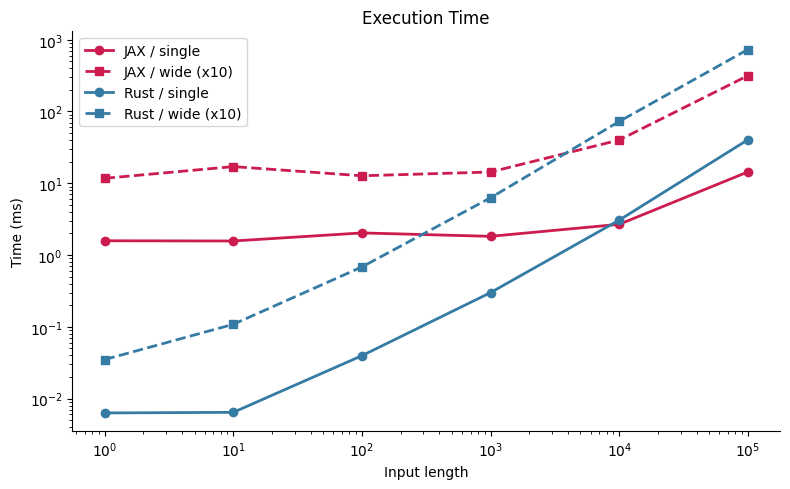

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))

backend_colors = {
    "JAX": sns.color_palette("rocket", 3)[1],
    "Rust": sns.color_palette("mako", 3)[1],
}
network_dashes = {"single": "-", "wide (x10)": "--"}
network_markers = {"single": "o", "wide (x10)": "s"}

for label, grp in df.groupby("Label"):
    backend = grp["Backend"].iloc[0]
    network = grp["Network"].iloc[0]
    ax.plot(
        grp["Input length"],
        grp["Time (ms)"],
        color=backend_colors[backend],
        linestyle=network_dashes[network],
        marker=network_markers[network],
        label=label,
        linewidth=2,
        markersize=6,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Input length")
ax.set_ylabel("Time (ms)")
ax.set_title("Execution Time")
ax.legend()

plt.tight_layout()
sns.despine()
plt.savefig("benchmark_results.pdf", dpi=300, bbox_inches="tight")
plt.show()